In [87]:
from IPython.display import HTML

def highlight_text(tokens, scores, cmap=('white', 'red'), html=True):
    """
    tokens: list of str
    scores: list of floats (positive = highlight more)
    """
    import numpy as np

    # Normalize scores to [0,1]
    s = np.array(scores, dtype=float)
    s = (s - s.min()) / (s.max() - s.min() + 1e-9)

    htmls = []
    for tok, sc in zip(tokens, s):
        color = f"rgba(255,0,0,{sc})"  # red with alpha=score
        htmls.append(f"<span style='background-color:{color}'>{tok}</span>")

    res = " ".join(htmls)

    if html:
        return HTML(res)
    else:
        return res

In [68]:
import pandas as pd

df = pd.read_json("../results/runtime_analysis4.json")
df.head()

,tokens,num_tokens,PartitionExplainer,HEDGE
0,"[, piercing, ]",1,"{'prediction_calls': 8, 'feature_importance': ...",NaN
1,"[, desert, ]",1,"{'prediction_calls': 8, 'feature_importance': ...",NaN
2,"[, honestly, ]",1,"{'prediction_calls': 8, 'feature_importance': ...","{'prediction_calls': 5, 'feature_importance': ..."
3,"[, crippled, ]",1,"{'prediction_calls': 8, 'feature_importance': ...","{'prediction_calls': 5, 'feature_importance': ..."
4,"[, aground, ]",1,"{'prediction_calls': 8, 'feature_importance': ...","{'prediction_calls': 5, 'feature_importance': ..."


In [5]:
df[df.num_tokens > 19].head()

,tokens,num_tokens,PartitionExplainer,HEDGE
190,"[, a, documentary, fails, to, live, up, ...",20,"{'prediction_calls': 364, 'feature_importance'...","{'prediction_calls': 7010, 'feature_importance..."
191,"[, is, an, insulting, ly, in, ept, and, ...",20,"{'prediction_calls': 396, 'feature_importance'...","{'prediction_calls': 6962, 'feature_importance..."
192,"[, on, the, worst, revenge, -, of, -, ...",20,"{'prediction_calls': 428, 'feature_importance'...","{'prediction_calls': 5586, 'feature_importance..."
193,"[, other, feel, -, good, fia, sco, s, li...",20,"{'prediction_calls': 428, 'feature_importance'...","{'prediction_calls': 5762, 'feature_importance..."
194,"[, a, visually, flash, y, but, narrative,...",20,"{'prediction_calls': 856, 'feature_importance'...","{'prediction_calls': 6530, 'feature_importance..."


In [65]:
s = df.iloc[190]
s

tokens                [,  a,  documentary,  fails,  to,  live,  up, ...
num_tokens                                                           20
PartitionExplainer    {'prediction_calls': 364, 'feature_importance'...
HEDGE                 {'prediction_calls': 7010, 'feature_importance...
Name: 190, dtype: object

In [15]:
tokens = s["tokens"][1:s["num_tokens"]+1]
fi_partition = s["PartitionExplainer"]["feature_importance"][1:s["num_tokens"]+1]
fi_hedge = s["HEDGE"]["feature_importance"][1:s["num_tokens"]+1]
fi_hedge

[-0.3619,
 -0.9077000000000001,
 0.9901000000000001,
 -0.8646,
 -0.9642000000000001,
 -0.9529000000000001,
 -0.8484,
 -0.8196,
 -0.7901,
 -0.6787000000000001,
 -0.21330000000000002,
 0.7286,
 -0.34840000000000004,
 -0.9952000000000001,
 -0.9226000000000001,
 -0.7433000000000001,
 -0.7658,
 -0.9571000000000001,
 -0.7486,
 -0.5703]

In [83]:
print("Partition Explainer:")
highlight_text(tokens, fi_partition)

Partition Explainer:


In [84]:
highlight_text(tokens, fi_partition, html=False)

In [20]:
print("HEDGE:")
highlight_text(tokens, fi_hedge)

HEDGE:


In [24]:
import shap
import transformers
from transformers import BertForSequenceClassification, BertTokenizer

model_dir = "../src/models/bert_IMDB"
model = BertForSequenceClassification.from_pretrained(model_dir)
tokenizer = BertTokenizer.from_pretrained(model_dir)


pred = transformers.pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        top_k=None
    )

explainer = shap.Explainer(pred)

Device set to use mps:0


In [33]:
sent = "".join(s["tokens"][1:])
sent

' a documentary fails to live up to - - or offer any new insight into - - its chosen topic'

In [34]:
shap_values = explainer([sent], max_evals=10000)

/Users/maor/Documents/Elia/thesis/text-explainability/venv/lib/python3.9/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/Users/maor/Documents/Elia/thesis/text-explainability/venv/lib/python3.9/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/Users/maor/Documents/Elia/thesis/text-explainability/venv/lib/python3.9/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [35]:
shap_values

.values =
array([[[ 0.        ,  0.        ],
        [-0.05382435,  0.05382434],
        [ 0.05227168, -0.05227167],
        [ 0.75327736, -0.75327738],
        [-0.00430597,  0.00430598],
        [-0.02195421,  0.02195421],
        [ 0.04681312, -0.04681311],
        [-0.02307418,  0.02307419],
        [ 0.01388508, -0.01388509],
        [-0.01456262,  0.01456264],
        [ 0.01430143, -0.01430144],
        [-0.01729515,  0.01729513],
        [ 0.10774984, -0.10774985],
        [ 0.03655385, -0.03655383],
        [-0.04758608,  0.04758607],
        [ 0.01676301, -0.016763  ],
        [ 0.03999677, -0.03999678],
        [-0.05033616,  0.05033616],
        [ 0.0455227 , -0.0455227 ],
        [-0.05266206,  0.05266206],
        [ 0.04588762, -0.04588762],
        [ 0.        ,  0.        ]]])

.base_values =
array([[0.11245091, 0.8875491 ]])

.data =
(array(['', ' a', ' documentary', ' fails', ' to', ' live', ' up', ' to',
       ' -', ' -', ' or', ' offer', ' any', ' new', ' insight',

In [38]:
s_cluster = explainer.masker.clustering(sent)
s_cluster

array([[ 0.        ,  1.        ,  0.09090909,  2.        ],
       [ 2.        ,  3.        ,  0.09090909,  2.        ],
       [ 4.        ,  5.        ,  0.09090909,  2.        ],
       [ 6.        ,  7.        ,  0.09090909,  2.        ],
       [ 8.        ,  9.        ,  0.09090909,  2.        ],
       [11.        , 12.        ,  0.09090909,  2.        ],
       [13.        , 14.        ,  0.09090909,  2.        ],
       [15.        , 16.        ,  0.09090909,  2.        ],
       [17.        , 18.        ,  0.09090909,  2.        ],
       [19.        , 20.        ,  0.09090909,  2.        ],
       [31.        , 21.        ,  0.13636364,  3.        ],
       [22.        , 23.        ,  0.18181818,  4.        ],
       [24.        , 25.        ,  0.18181818,  4.        ],
       [27.        , 28.        ,  0.18181818,  4.        ],
       [29.        , 30.        ,  0.18181818,  4.        ],
       [26.        , 10.        ,  0.13636364,  3.        ],
       [34.        , 37.

In [42]:
ntokens = len(s["tokens"])
print(f"{ntokens} tokens")

22 tokens


In [52]:
s["PartitionExplainer"]["feature_importance"]

[0.0,
 -0.053824346163310006,
 0.05227167514385601,
 0.753277358424384,
 -0.004305971626308001,
 -0.021954205629299003,
 0.046813118853606006,
 -0.023074183845892,
 0.013885081629268001,
 -0.014562621363438001,
 0.01430142764002,
 -0.017295148572884,
 0.107749842223711,
 0.036553850222844006,
 -0.047586084867361,
 0.016763007384724003,
 0.039996771374717,
 -0.050336163723841004,
 0.045522699714638,
 -0.05266206213855101,
 0.045887615444371005,
 0.0]

In [70]:
df.iloc[190]["PartitionExplainer"]

{'prediction_calls': 364,
 'feature_importance': [0.0,
  -0.053824346163310006,
  0.05227167514385601,
  0.753277358424384,
  -0.004305971626308001,
  -0.021954205629299003,
  0.046813118853606006,
  -0.023074183845892,
  0.013885081629268001,
  -0.014562621363438001,
  0.01430142764002,
  -0.017295148572884,
  0.107749842223711,
  0.036553850222844006,
  -0.047586084867361,
  0.016763007384724003,
  0.039996771374717,
  -0.050336163723841004,
  0.045522699714638,
  -0.05266206213855101,
  0.045887615444371005,
  0.0]}

In [75]:
s = df.iloc[190].copy()

# Initialize groups as single tokens
groups = s["tokens"].copy()
group_levels = [groups.copy()]
#print(groups)

groups_fi = s["PartitionExplainer"]["feature_importance"].copy()
highlight_text(groups, groups_fi)

In [80]:
htmls

[<IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>,
 <IPython.core.display.HTML object>]

In [88]:
s = df.iloc[190].copy()

# Initialize groups as single tokens
groups = s["tokens"].copy()
group_levels = [groups.copy()]
#print(groups)

groups_fi = s["PartitionExplainer"]["feature_importance"].copy()
htmls = [highlight_text(groups, groups_fi, html=False)]
hier_tree = [{"groups": groups.copy(),
             "fi": groups_fi.copy()}]

# Keep groups indices, initially before it's just the positions of the token,
# but after merging groups, the index holds the position of the current group
groups_indices = list(range(len(groups)))

# For each merge:
for i in range(len(s_cluster)):
    # Get indices of groups to merge
    current_merge = s_cluster[i]
    left_group = groups_indices[int(current_merge[0])]
    right_group = groups_indices[int(current_merge[1])]

    # Merge the relevant tokens as a new group
    groups[left_group] = groups[left_group] + " " + groups[right_group]

    # Remove redundant group
    groups.pop(right_group)
    #group_levels.append(groups)

    # Sum the feature importance score to the new score and remove the old score
    groups_fi[left_group] += groups_fi[right_group]
    groups_fi.pop(right_group)
    htmls.append(highlight_text(groups, groups_fi, html=False))
    hier_tree.append([{"groups": groups.copy(),
             "fi": groups_fi.copy()}])

    # Update all groups indices 
    for i in range(len(groups_indices)):
        if groups_indices[i] > left_group:
            groups_indices[i] = groups_indices[i] - 1
    
    # Add new index group to list
    groups_indices.append(left_group)
        
    # Print the groups
    #print(groups)

HTML("<br><br>".join(htmls))

In [92]:
len(hier_tree)

22

In [95]:
hier_tree[12]

[{'groups': ['  a  documentary  fails',
   ' to  live',
   ' up  to',
   ' -  -',
   ' or',
   ' offer  any',
   ' new  insight',
   ' into  -',
   ' -  its',
   ' chosen  topic '],
  'fi': [0.75172468740493,
   -0.026260177255607003,
   0.023738935007714006,
   -0.0006775397341700004,
   0.01430142764002,
   0.090454693650827,
   -0.011032234644516997,
   0.05675977875944101,
   -0.004813464009203003,
   -0.006774446694180002]}]

In [ ]:
def aopc(feature_importance_scores, tokens, prediction_func, mask_value):
    full_prediction = prediction_func(tokens)
    fp_max, fp_max_ind = np.max(full_prediction), np.argmax(full_prediction)
    sub_fi_scores = feature_importance_scores[1:len(feature_importance_scores)-1]
    n_features = len(sub_fi_scores)

    # Features indices highest to lowest
    sorted_indices = np.argsort(sub_fi_scores)[::-1]
    sorted_indices += 1
    sum_diff = 0
    print(f"Prediction: {fp_max}, class {fp_max_ind}")

    for k in range(1, n_features + 1):
        modified_input = tokens.copy()
        top_k_indices = sorted_indices[:k]
        modified_input[top_k_indices] = mask_value
        k_prediction = prediction_func(modified_input)
        k_prediction = k_prediction[fp_max_ind]
        sum_diff += (fp_max - k_prediction)
        print(f"{k}. diff {(fp_max - k_prediction)}")

    aopc = sum_diff / n_features
    print(f"aopc: {aopc}")
    return aopc, fp_max, fp_max_ind


def bert_aopc(model, tokenizer, text, feature_importance_scores):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    input_ids = inputs['input_ids'][0]  # Remove batch dimension
    attention_mask = inputs['attention_mask'][0]

    def prediction_func(token_ids):
        """Returns class probabilities for given token IDs."""
        # Convert to tensor if needed
        if isinstance(token_ids, np.ndarray):
            token_ids = torch.tensor(token_ids).unsqueeze(0)
        elif isinstance(token_ids, list):
            token_ids = torch.tensor(token_ids).unsqueeze(0)
        else:
            token_ids = token_ids.unsqueeze(0)

        # Create attention mask (1 for real tokens, 0 for padding)
        attn_mask = (token_ids != tokenizer.pad_token_id).long()

        with torch.no_grad():
            outputs = model(input_ids=token_ids, attention_mask=attn_mask)
            probabilities = torch.softmax(outputs.logits, dim=-1)

        return probabilities[0].cpu().numpy()

    # Calculate AOPC
    print(text)
    mask_token_id = tokenizer.mask_token_id
    tokens_numpy = input_ids.cpu().numpy()

    aopc_score, fp_max, fp_max_ind = aopc(
        feature_importance_scores,
        tokens_numpy,
        prediction_func,
        mask_token_id
    )

    return aopc_score, fp_max, fp_max_ind

In [ ]:
for tree_level in hier_tree:
    level_aopc = aopc(model, tokenizer, tree_level['groups'], tree_level['fi'])

Examples for presentation

In [108]:

for i in range(100,200):
    print("".join(df.iloc[i]["tokens"]))

 did n ' t connect with me would require another viewing
 to its last - minute , haphazard theatrical release
 evaporates like so much crypt mist in the brain
 it is an interesting exercise by talented writer / director anderson
 takes a really long , slow and dreary time
 has finally , to some extent , warmed up to him
 drag along the dead ( water ) weight of the other
 oversimplification , superficiality and silliness
 you do n ' t care who fires the winning shot
 of whimsicality , narrative discipline and serious improvisation
 a wild comedy that could only spring from the demented mind
 ' ll find yourself remembering this refreshing visit to a sunshine state
 that ' s old - fashioned in all the best possible ways
 sporadic bursts of liveliness , some so - so slapstick
 like a bunch of talented thesps slumming it
 pushing the jokes at the expense of character until things fall apart
 comedy that takes an astonishingly condescending attitude toward women
 i have always appreciated a 

In [109]:
#s = df.iloc[190]
# s_cluster = explainer.masker.clustering(sent)
# sent = "".join(s["tokens"][1:])
example_s = "It starts interesting, but it gets boring halfway through."
example_cluster = explainer.masker.clustering(example_s)

In [96]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

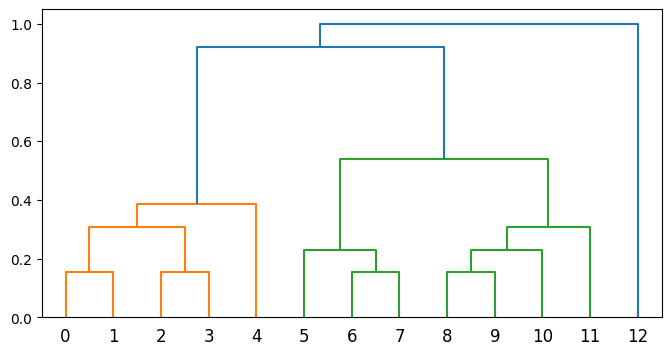

In [110]:
fig = plt.figure(figsize=(8, 4))
dn = dendrogram(example_cluster)
plt.show()


In [117]:
examples_tokens = explainer.masker.tokenizer(example_s)
fig = plt.figure(figsize=(12, 6))
dn = dendrogram(
    example_cluster,
    labels=examples_tokens,  # Add token labels
    leaf_rotation=90,  # Rotate labels for better readability
    leaf_font_size=10
)
plt.xlabel('Tokens')
plt.ylabel('Distance')
plt.title('Text Partition Tree')
plt.tight_layout()
plt.show()

ValueError: Dimensions of Z and labels must be consistent.

<Figure size 1200x600 with 0 Axes>

In [114]:
len(examples_tokens["input_ids"])

13

In [120]:
example_cluster

array([[ 0.        ,  1.        ,  0.15384615,  2.        ],
       [ 2.        ,  3.        ,  0.15384615,  2.        ],
       [ 6.        ,  7.        ,  0.15384615,  2.        ],
       [ 8.        ,  9.        ,  0.15384615,  2.        ],
       [16.        , 10.        ,  0.23076923,  3.        ],
       [13.        , 14.        ,  0.30769231,  4.        ],
       [ 5.        , 15.        ,  0.23076923,  3.        ],
       [17.        , 11.        ,  0.30769231,  4.        ],
       [18.        ,  4.        ,  0.38461538,  5.        ],
       [19.        , 20.        ,  0.53846154,  7.        ],
       [21.        , 22.        ,  0.92307692, 12.        ],
       [23.        , 12.        ,  1.        , 13.        ]])

Number of tokens: 13
Clustering shape: (12, 4)
Tokens: ['[CLS]', 'it', 'starts', 'interesting', ',', 'but', 'it', 'gets', 'boring', 'halfway', 'through', '.', '[SEP]']


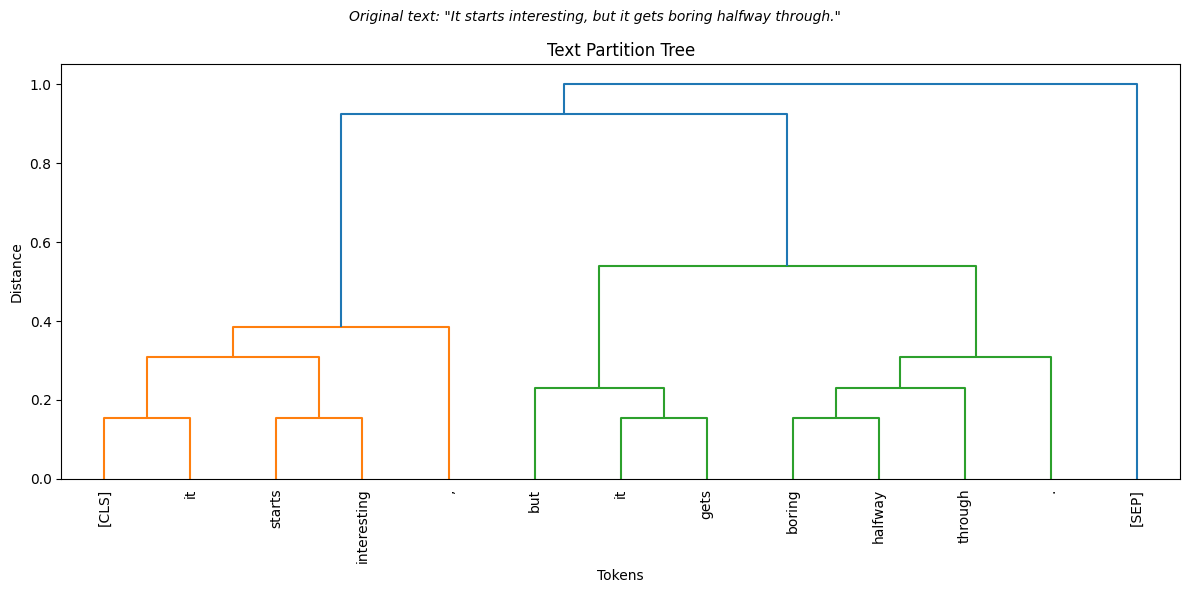

In [126]:
import numpy as np

example_tokens = explainer.masker.tokenizer(example_s)

# Convert each token ID to its text representation
example_tokens = [tokenizer.decode([token_id]) for token_id in example_tokens['input_ids']]

print(f"Number of tokens: {len(example_tokens)}")
print(f"Clustering shape: {example_cluster.shape}")  # Should be (12, 4)
print(f"Tokens: {example_tokens}")

fig = plt.figure(figsize=(12, 6))
dn = dendrogram(
    example_cluster,
    labels=example_tokens,  # This should work now - 13 labels for 13 leaves
    leaf_rotation=90,
    leaf_font_size=10
)
plt.xlabel('Tokens')
plt.ylabel('Distance')
plt.title('Text Partition Tree')
# Add the sentence as a subtitle
plt.suptitle(f'Original text: "{example_s}"', 
             fontsize=10, 
             style='italic',
             y=0.98)  # Adjust position

plt.tight_layout()
plt.show()

In [123]:
example_tokens

{'input_ids': [101, 2009, 4627, 5875, 1010, 2021, 2009, 4152, 11771, 8576, 2083, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}